Fold 1 AUC: 0.92310
Fold 2 AUC: 0.92239
Fold 3 AUC: 0.92100
Fold 4 AUC: 0.92191
Fold 5 AUC: 0.92147
\nOverall CV AUC: 0.92197

--- Top 20 Most Important Features ---
                                        feature    importance
0       annual_income_mean_by_employment_status  1.756574e+06
1                                  default_risk  5.680358e+05
2                          debt_to_income_ratio  1.533949e+05
3                                  credit_score  4.442635e+04
4                                grade_subgrade  3.546095e+04
5                                 interest_rate  1.905435e+04
6                          TE_employment_status  1.722218e+04
7                                   loan_amount  1.038214e+04
8                                 annual_income  8.453154e+03
9                               TE_loan_purpose  8.079768e+03
10                              loan_amount_d-2  7.969355e+03
11                            TE_grade_subgrade  7.948416e+03
12     loan_amount_ratio_to_

C:\Users\mateu\AppData\Local\Temp\ipykernel_6080\2344909851.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


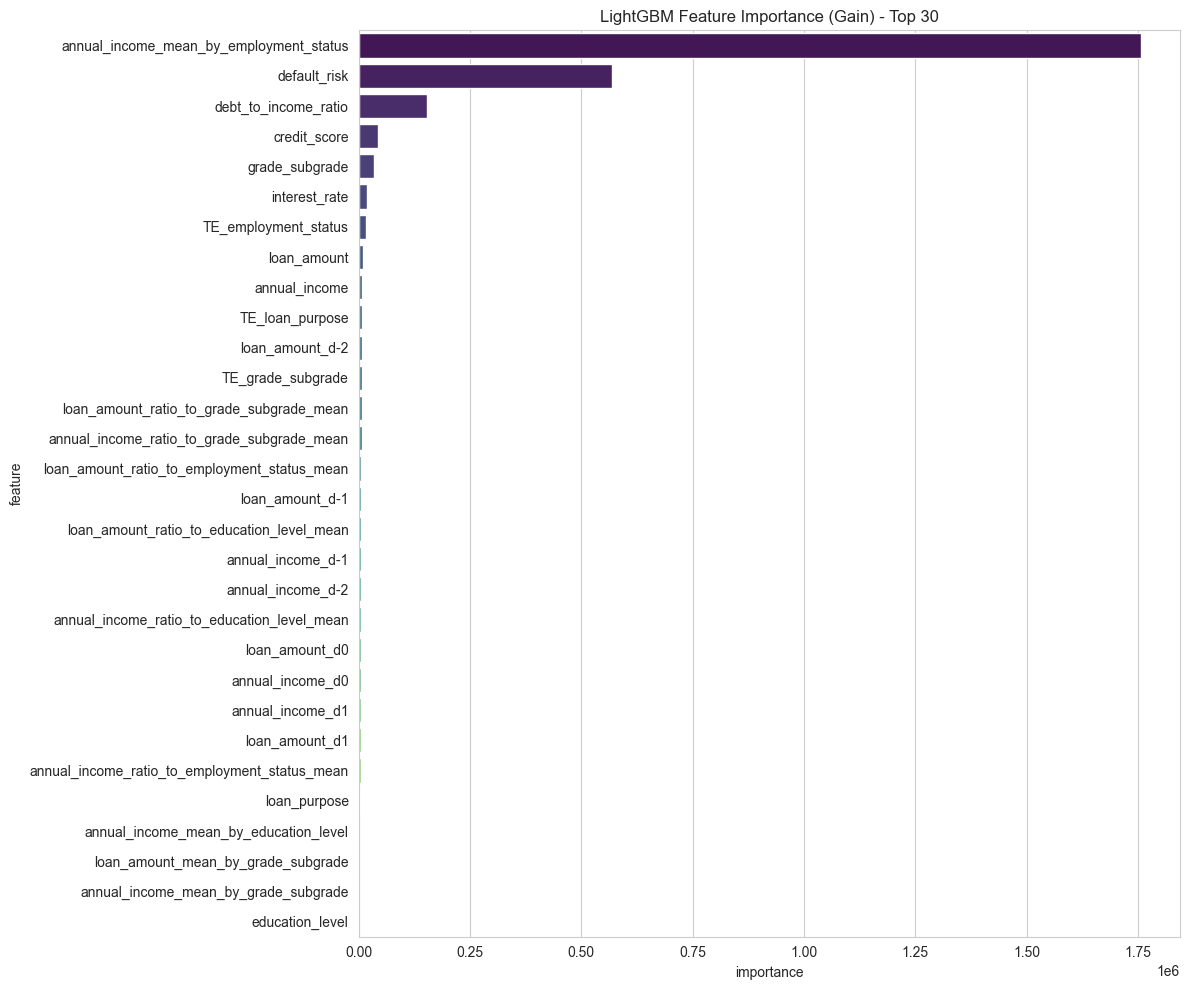

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import TargetEncoder
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import gc

TARGET = 'loan_paid_back'
NUMS = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
CATS = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

train = pd.read_csv('train.csv', index_col = 'id')
test = pd.read_csv('test.csv', index_col = 'id')

feature_importances = []

# Cechy na podstawie wiedzy domenowej
## wagi dobrane prawdopodobnie na czute (potencjalnie do optymalizacji)
train['default_risk'] = (train['debt_to_income_ratio'] * 0.4 +
                         (850 - train['credit_score']) / 850 * 0.35 +
                         train['interest_rate'] / 100 * 0.25)

test['default_risk'] = (test['debt_to_income_ratio'] * 0.40 +
                        (850 - test['credit_score']) / 850 * 0.35 +
                        test['interest_rate'] / 100 * 0.25)

# Trick z modulo
for c in ['annual_income', 'loan_amount']:
    for k in range(-2, 2):
        n = f'{c}_d{k}'
        train[n] = ((train[c] * 10**k) % 10).fillna(-1).astype("int8")
        test[n] = ((test[c] * 10**k) % 10).fillna(-1).astype("int8")

# Agregacje Grupowe
AGG_COLS = ['annual_income', 'loan_amount']
GROUP_COLS = ['education_level', 'grade_subgrade', 'employment_status']

for group_col in GROUP_COLS:
    for agg_col in AGG_COLS:
        combined_df = pd.concat([train[[group_col, agg_col]], test[[group_col, agg_col]]])
        group_mean = combined_df.groupby(group_col)[agg_col].mean()

        new_col_name = f'{agg_col}_mean_by_{group_col}'
        train[new_col_name] = train[group_col].map(group_mean).astype('float32')
        test[new_col_name] = test[group_col].map(group_mean).astype('float32')

        ratio_col_name = f'{agg_col}_ratio_to_{group_col}_mean'
        train[ratio_col_name] = (train[agg_col] / train[new_col_name]).astype('float32')
        test[ratio_col_name] = (test[agg_col] / test[new_col_name]).astype('float32')

# Specyficzny encoding pod LightGbm (nie jestem przekonany czy to ma sens, ale można zobaczyć)
train['grade_subgrade_d1'] = train['grade_subgrade'].apply(lambda x: x[1] if pd.notnull(x) else '-1')
test['grade_subgrade_d1'] = test['grade_subgrade'].apply(lambda x: x[1] if pd.notnull(x) else '-1')
CATS.append('grade_subgrade_d1')

for c in CATS:
    train[c] = train[c].astype('category')
    test[c] = test[c].astype('category')

FEATURES = [col for col in train.columns if col != TARGET]
TE_COLS = ['employment_status', 'loan_purpose', 'grade_subgrade']

skf = StratifiedKFold(n_splits = 5, random_state = 42, shuffle  = True)
oof_preds = np.zeros(len(train))
test_preds = np.zeros(len(test))

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'random_state': 42,
    'n_estimators': 2000,
    'verbose' : -1,
    'n_jobs': -1
}

for fold, (train_idx, val_idx) in enumerate(skf.split(train, train[TARGET])):
    X_train, y_train = train.iloc[train_idx][FEATURES].copy(), train.iloc[train_idx][TARGET]
    X_val, y_val = train.iloc[val_idx][FEATURES].copy(), train.iloc[val_idx][TARGET]
    X_test_fold = test[FEATURES].copy()

    for col in TE_COLS:
        encoder = TargetEncoder(cv=5, random_state=42)
        new_col = f'TE_{col}'
        X_train[new_col] = encoder.fit_transform(X_train[[col]], y_train)
        X_val[new_col] = encoder.transform(X_val[[col]])
        X_test_fold[new_col] = encoder.transform(X_test_fold[[col]])

    current_features = X_train.columns.tolist()

    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
    )

    fold_importance = pd.DataFrame({
        'feature': current_features,
        'importance': model.booster_.feature_importance(importance_type='gain'),
        'fold': fold + 1
    })
    feature_importances.append(fold_importance)

    oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
    test_preds += model.predict_proba(X_test_fold[current_features])[:, 1] / skf.n_splits

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    print(f"Fold {fold + 1} AUC: {fold_auc:.5f}")

    del X_train, y_train, X_val, y_val, X_test_fold, model, current_features
    gc.collect()

cv_auc = roc_auc_score(train[TARGET], oof_preds)
print(f"\\nOverall CV AUC: {cv_auc:.5f}")

importance_df = pd.concat(feature_importances, axis=0)
mean_importance = importance_df.groupby('feature')['importance'].mean().sort_values(ascending=False).reset_index()

print("\n--- Top 20 Most Important Features ---")
print(mean_importance.head(20))

print("\n--- Bottom 15 Least Important Features (Candidates for removal) ---")
print(mean_importance.tail(15))

plt.figure(figsize=(12, 10))
sns.barplot(
    x='importance',
    y='feature',
    data=mean_importance.head(30),
    palette='viridis'
)
plt.title('LightGBM Feature Importance (Gain) - Top 30')
plt.tight_layout()
plt.show()

pd.DataFrame({'id': train.index, 'lgbm_oof': oof_preds}).to_csv('lgbm_baseline_oof.csv', index=False)